<a href="https://colab.research.google.com/github/praveenkumarrlgmp-source/meachin-learing-project/blob/main/Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (1000, 9)

First 5 Rows:
   Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
0            2  115.863387      56.410731      24.336736   94.385783   
1            2   92.490122      70.615520      23.443591  138.652426   
2            1   88.141469      63.262618      23.404364  149.358082   
3            2  108.453101      67.793632      20.751580  108.751638   
4            1  127.849443      94.725685      22.603078   25.269987   

         BMI  DiabetesPedigreeFunction        Age  Diagnosis  
0  26.455940                  0.272682  20.100494          0  
1  23.910167                  0.665160  44.912281          0  
2  21.948250                  0.676022  48.247873          1  
3  24.209304                  0.289636  42.749868          0  
4  32.997477                  0.601315  32.797789          0  

Column Names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Diagnosis']

Missin

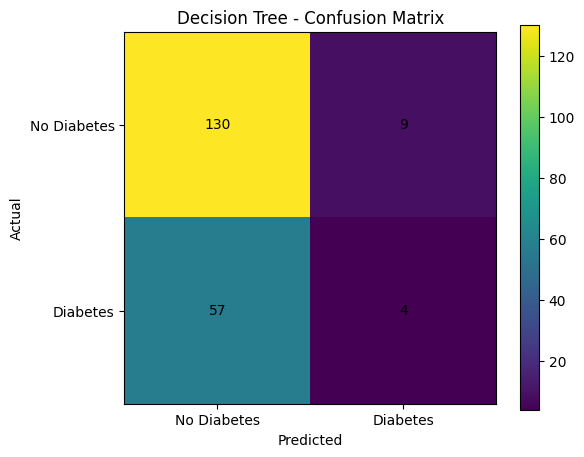

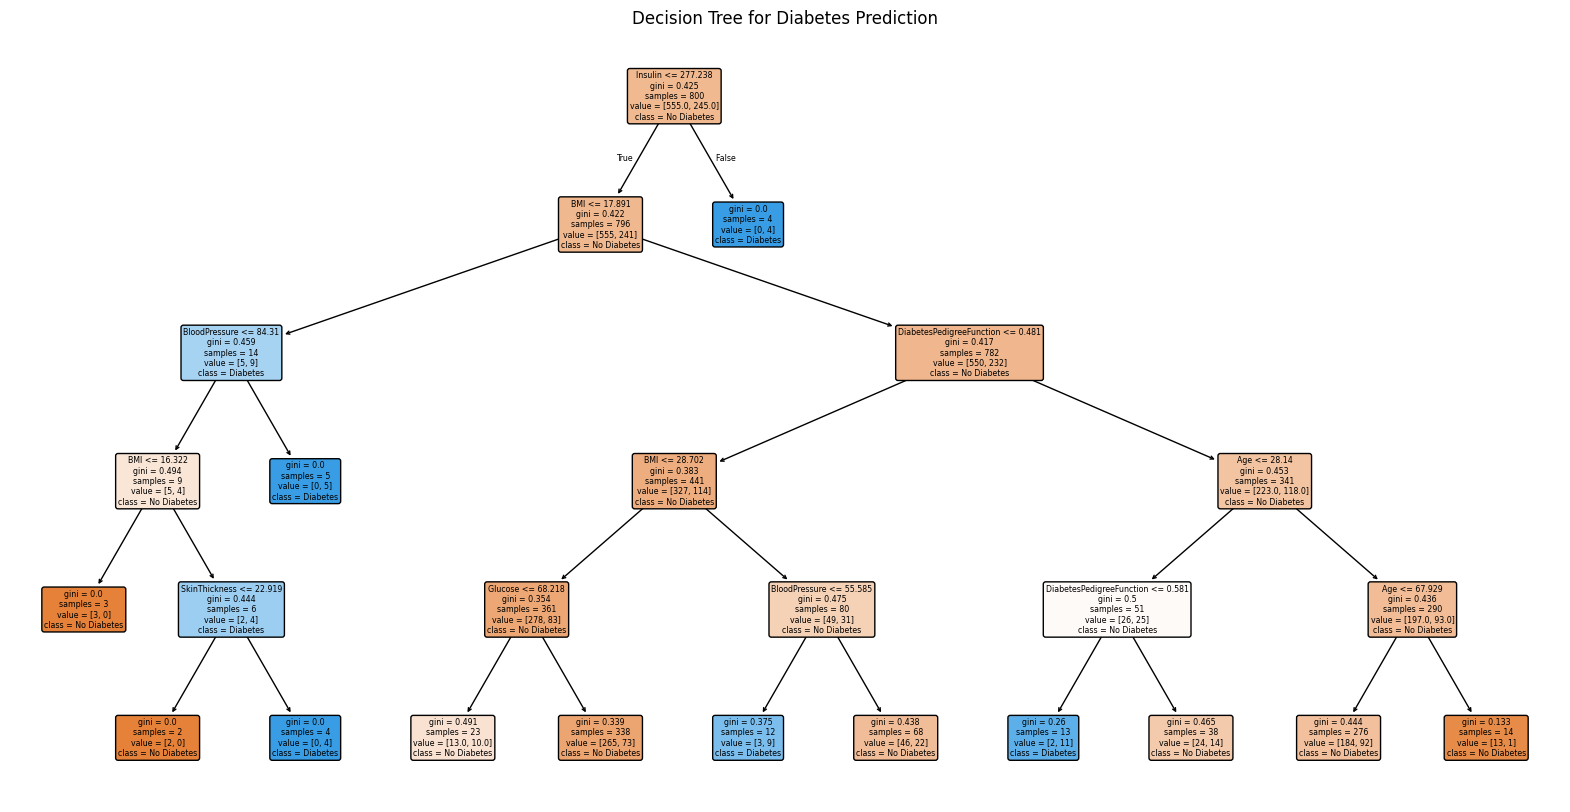

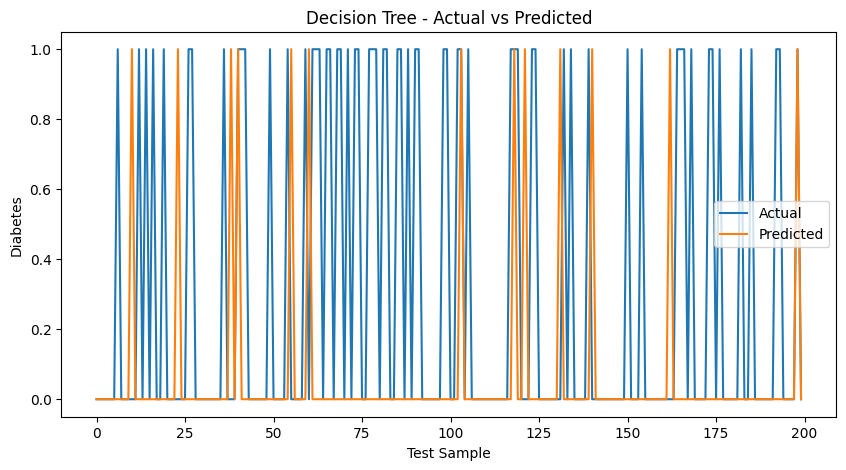

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# ==========================================
# 1. LOAD DATASET
# ==========================================

df = pd.read_csv("/content/Diabetes_prediction.csv")

print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())

print("\nColumn Names:")
print(df.columns.tolist())


# ==========================================
# 2. CHECK MISSING VALUES
# ==========================================

print("\nMissing Values:")
print(df.isnull().sum())


# ==========================================
# 3. SEPARATE FEATURES AND TARGET
# ==========================================

X = df.drop("Diagnosis", axis=1)

y = df["Diagnosis"]


# ==========================================
# 4. TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# ==========================================
# 5. CREATE DECISION TREE
# ==========================================

model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=42
)


# ==========================================
# 6. TRAIN MODEL
# ==========================================

model.fit(
    X_train,
    y_train
)


# ==========================================
# 7. PREDICTION
# ==========================================

y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]


# ==========================================
# 8. MODEL EVALUATION
# ==========================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)


print("\n======================================")
print("DECISION TREE RESULTS")
print("======================================")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")


# ==========================================
# 9. CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)


# ==========================================
# 10. CLASSIFICATION REPORT
# ==========================================

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "No Diabetes",
            "Diabetes"
        ],
        zero_division=0
    )
)


# ==========================================
# 11. CONFUSION MATRIX GRAPH
# ==========================================

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Decision Tree - Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.xticks(
    [0, 1],
    ["No Diabetes", "Diabetes"]
)

plt.yticks(
    [0, 1],
    ["No Diabetes", "Diabetes"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.show()


# ==========================================
# 12. DECISION TREE GRAPH
# ==========================================

plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=[
        "No Diabetes",
        "Diabetes"
    ],
    filled=True,
    rounded=True
)

plt.title("Decision Tree for Diabetes Prediction")

plt.show()


# ==========================================
# 13. ACTUAL VS PREDICTED GRAPH
# ==========================================

plt.figure(figsize=(10, 5))

plt.plot(
    y_test.values,
    label="Actual"
)

plt.plot(
    y_pred,
    label="Predicted"
)

plt.xlabel("Test Sample")

plt.ylabel("Diabetes")

plt.title(
    "Decision Tree - Actual vs Predicted"
)

plt.legend()

plt.show()